In [1]:
import pandas as pd
import numpy as np
import re

In [2]:
df = pd.read_csv(r'C:\Users\apaks\Desktop\Real Estate Project\artifacts\data\preprocessed-data\gurgaon_properties_cleaned_v1.csv', index_col = 0)

In [3]:
df.head()

,property_type,society,sector,price_in_cr,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features
0,house,independent,sector 105,0.60,11102.0,(50 sq.m.) Plot Area,Plot area 60(50.17 sq.m.),8,4,3,not available,3.0,West,0 to 1 Year Old,"['Chintapurni Mandir', 'State bank ATM', 'Bhar...","['9 Fan', '17 Light', 'No AC', 'No Bed', 'No C...","['Private Garden / Terrace', 'Park']"
1,flat,vatika gurgaon,sector 83,1.18,6801.0,1735.04,Super Built up area 1735(161.19 sq.m.)Carpet a...,3,3,2,not available,14.0,north,1 to 5 Year Old,"['Huda Metro Station (Gurugram)', 'Sapphire 83...",NaN,"['Feng Shui / Vaastu Compliant', 'Lift(s)', 'M..."
2,flat,emaar digihomes,sector 62,4.00,14871.0,2689.8,Super Built up area 2588.79(240.51 sq.m.),3,3,3,servant room,18.0,north,0 to 1 Year Old,"['Sector 55-56 Metro Station', 'Omaxe Gurgaon ...","['6 Fan', '7 Light', '8 AC', '1 Modular Kitche...","['High Ceiling Height', 'Maintenance Staff', '..."
3,flat,ss the leaf,sector 85,1.10,6318.0,1741.06,Super Built up area 1741(161.74 sq.m.)Carpet a...,2,2,3+,store room,3.0,south-east,1 to 5 Year Old,"['Sapphire 83 Mall', 'Dwarka Expressway', 'Cen...","['10 Light', '4 AC', 'No Bed', 'No Chimney', '...","['Centrally Air Conditioned', 'Water purifier'..."
4,flat,tarc maceo,sector 91,0.89,6339.0,1404.01,Super Built up area 1404(130.44 sq.m.)Carpet a...,2,2,3+,others,9.0,east,1 to 5 Year Old,"['Manish Gallexie 91', 'Dwarka Expressway', 'R...","['2 Wardrobe', '5 Fan', '1 Exhaust Fan', '1 Ge...","['Intercom Facility', 'Lift(s)', 'Maintenance ..."


### area and areaWithType columns

In [4]:
# pd.set_option('display.max_rows', None)
# pd.set_option('display.max_columns', None)
# # pd.set_option('display.max_colwidth', None)

In [5]:
df[['area', 'areaWithType']]

,area,areaWithType
0,(50 sq.m.) Plot Area,Plot area 60(50.17 sq.m.)
1,1735.04,Super Built up area 1735(161.19 sq.m.)Carpet a...
2,2689.8,Super Built up area 2588.79(240.51 sq.m.)
3,1741.06,Super Built up area 1741(161.74 sq.m.)Carpet a...
4,1404.01,Super Built up area 1404(130.44 sq.m.)Carpet a...
...,...,...
3956,1790.21,Super Built up area 1790(166.3 sq.m.)
3957,(420 sq.m.) Plot Area,Plot area 502(419.74 sq.m.)
3958,1502.68,Super Built up area 1381(128.3 sq.m.)
3959,2290.28,Super Built up area 2290(212.75 sq.m.)


- area column contains randomly either superbuiltup or built up or carpet area
- areawithtype contains the area (superbuiltup, builtup, carpet area)
- not all properties have all the types of areas available
- houses have plot area

In [6]:
df['areaWithType']

0                               Plot area 60(50.17 sq.m.)
1       Super Built up area 1735(161.19 sq.m.)Carpet a...
2               Super Built up area 2588.79(240.51 sq.m.)
3       Super Built up area 1741(161.74 sq.m.)Carpet a...
4       Super Built up area 1404(130.44 sq.m.)Carpet a...
                              ...                        
3956                Super Built up area 1790(166.3 sq.m.)
3957                          Plot area 502(419.74 sq.m.)
3958                Super Built up area 1381(128.3 sq.m.)
3959               Super Built up area 2290(212.75 sq.m.)
3960                   Built Up area: 1295 (120.31 sq.m.)
Name: areaWithType, Length: 3790, dtype: str

In [7]:
# extract superbuiltup area from text. eg Super Built up area 1735(161.19 sq.m.)

def extract_super_builtup_area(text: str):
    match = re.search(r'Super Built up area (\d+\.?\d*)', text)
    if match:
        return float(match.group(1))
    return None

extract_super_builtup_area('Super Built up area 1758(163.32 sq.m.)Carpet area: 1558 sq.ft. (144.74')

1758.0

In [8]:
# extract built up area area from text. from eg Super Built up area 1360(126.35 sq.m.)Built Up area: 1260 sq.ft. (117.06 sq.m.)Carpet area: 894 sq.ft. (83.06

def extract_builtup_area(text):
    match = re.search(r'Built Up area: (\d+\.?\d*)', text)
    if match:
        return float(match.group(1))
    return None

extract_builtup_area('Super Built up area 1360(126.35 sq.m.)Built Up area: 1260 sq.ft. (117.06 sq.m.)Carpet area: 894 sq.ft. (83.06')
extract_builtup_area('Built Up area: 3400 (315.87 sq.m.)Carpet area: 1836 sq.ft. (170.57')

3400.0

In [9]:
# extract carpet area

def extract_carpet_area(text):
    match = re.search(r'Carpet area: (\d+\.?\d*)', text)
    if match:
        return float(match.group(1))
    return None

extract_carpet_area('Super Built up area 1360(126.35 sq.m.)Built Up area: 1260 sq.ft. (117.06 sq.m.)Carpet area: 894 sq.ft. (83.06')

894.0

In [10]:
# convert all values to sq ft

def convert_to_sqft(text, area):
    if area is None:
        return None
    match = re.search(rf'{area}.*\((\d+\.?\d*) sq.m.\)', text)
    if match:
        sqm_area = float(match.group(1))
        return round(sqm_area * 10.7639, 2)
    return area

print(convert_to_sqft('Super Built up area 1360(126.35 sq.m.)Built Up area: 1260 sq.ft. (117.06 sq.m.)Carpet area: 894 sq.ft. (83.06', 1260))

1260.02


In [11]:
df.head()

,property_type,society,sector,price_in_cr,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features
0,house,independent,sector 105,0.60,11102.0,(50 sq.m.) Plot Area,Plot area 60(50.17 sq.m.),8,4,3,not available,3.0,West,0 to 1 Year Old,"['Chintapurni Mandir', 'State bank ATM', 'Bhar...","['9 Fan', '17 Light', 'No AC', 'No Bed', 'No C...","['Private Garden / Terrace', 'Park']"
1,flat,vatika gurgaon,sector 83,1.18,6801.0,1735.04,Super Built up area 1735(161.19 sq.m.)Carpet a...,3,3,2,not available,14.0,north,1 to 5 Year Old,"['Huda Metro Station (Gurugram)', 'Sapphire 83...",NaN,"['Feng Shui / Vaastu Compliant', 'Lift(s)', 'M..."
2,flat,emaar digihomes,sector 62,4.00,14871.0,2689.8,Super Built up area 2588.79(240.51 sq.m.),3,3,3,servant room,18.0,north,0 to 1 Year Old,"['Sector 55-56 Metro Station', 'Omaxe Gurgaon ...","['6 Fan', '7 Light', '8 AC', '1 Modular Kitche...","['High Ceiling Height', 'Maintenance Staff', '..."
3,flat,ss the leaf,sector 85,1.10,6318.0,1741.06,Super Built up area 1741(161.74 sq.m.)Carpet a...,2,2,3+,store room,3.0,south-east,1 to 5 Year Old,"['Sapphire 83 Mall', 'Dwarka Expressway', 'Cen...","['10 Light', '4 AC', 'No Bed', 'No Chimney', '...","['Centrally Air Conditioned', 'Water purifier'..."
4,flat,tarc maceo,sector 91,0.89,6339.0,1404.01,Super Built up area 1404(130.44 sq.m.)Carpet a...,2,2,3+,others,9.0,east,1 to 5 Year Old,"['Manish Gallexie 91', 'Dwarka Expressway', 'R...","['2 Wardrobe', '5 Fan', '1 Exhaust Fan', '1 Ge...","['Intercom Facility', 'Lift(s)', 'Maintenance ..."


In [12]:
df.columns

Index(['property_type', 'society', 'sector', 'price_in_cr', 'price_per_sqft',
       'area', 'areaWithType', 'bedRoom', 'bathroom', 'balcony',
       'additionalRoom', 'floorNum', 'facing', 'agePossession',
       'nearbyLocations', 'furnishDetails', 'features'],
      dtype='str')

In [13]:
df['super_built_up_area'] = df['areaWithType'].apply(extract_super_builtup_area)
df['super_built_up_area'] = df.apply(lambda x : convert_to_sqft(text= x['areaWithType'], area = x['super_built_up_area']), axis= 1)

In [14]:
df['built_up_area'] = df['areaWithType'].apply(extract_builtup_area)
df['built_up_area'] = df.apply(lambda x : convert_to_sqft(text= x['areaWithType'], area = x['built_up_area']), axis= 1)

In [15]:
df['carpet_area'] = df['areaWithType'].apply(extract_carpet_area)
df['carpet_area'] = df.apply(lambda x : convert_to_sqft(text= x['areaWithType'], area = x['carpet_area']), axis= 1)

In [16]:
pd.reset_option('display.max_colwidth')

In [17]:
df.sample(5)

,property_type,society,sector,price_in_cr,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,super_built_up_area,built_up_area,carpet_area
2054,flat,imperia the esfera,sector 37,0.86,4886.0,1760.13,Super Built up area 1760(163.51 sq.m.),3,3,2,others,0.0,NaN,0 to 1 Year Old,"['Approved Sector 37 Mero Station', 'Esplanade...",NaN,"['Feng Shui / Vaastu Compliant', 'Lift(s)', 'M...",1760.0,NaN,NaN
817,flat,ireo the grand arch,sector 58,2.20,13480.0,1632.05,Super Built up area 1632(151.62 sq.m.)Built Up...,2,2,1,study room,5.0,north-east,1 to 5 Year Old,"['Sector 55-56 Rapid Metro', 'Paras Trinity Ma...","['6 Fan', '1 Exhaust Fan', '2 Geyser', '1 Stov...","['Power Back-up', 'Feng Shui / Vaastu Complian...",1632.0,1432.0,1232.0
3406,flat,parsvnath green ville,sector 48,1.60,8376.0,1910.22,Super Built up area 1910(177.44 sq.m.)Built Up...,3,3,3+,others,8.0,north,10+ Year Old,"['Sri Radhe Krishna Temple', 'Icici bank ATM',...","['8 Fan', '1 Exhaust Fan', '3 Geyser', '3 Ligh...","['Feng Shui / Vaastu Compliant', 'Security / F...",1910.0,1895.0,1800.0
380,house,international city by sobha phase 2,sector 109,6.25,10035.0,(579 sq.m.) Plot Area,Plot area 692(578.6 sq.m.),5,7,3+,"pooja room,study room,servant room,store room",3.0,North-East,1 to 5 Year Old,"['Dwarka Sector 21 Metro Station', 'Pacific D2...",NaN,"['Security / Fire Alarm', 'Feng Shui / Vaastu ...",NaN,NaN,NaN
2602,flat,signature global the millennia,sector 37,0.55,9166.0,600.04,Super Built up area 850(78.97 sq.m.)Built Up a...,2,2,3,not available,3.0,NaN,0 to 1 Year Old,"['Jharsha Chowk', 'Hero Honda Chowk', 'Rajiv C...",NaN,"['Feng Shui / Vaastu Compliant', 'Intercom Fac...",850.0,610.0,600.0


In [18]:
df[df['areaWithType'].str.contains('Plot')].shape

(678, 20)

- for houses plot area is same as built up area

In [19]:
def extract_plot_area(text):
    match = re.search(r'Plot area (\d+\.?\d*)', text)
    if match:
        return float(match.group(1))
    return None

extract_plot_area('Plot area 360(301.01 sq.m.)')

360.0

In [20]:
df[df['built_up_area'].isnull()]['property_type']

0       house
1        flat
2        flat
3        flat
4        flat
        ...  
3954     flat
3956     flat
3957    house
3958     flat
3959     flat
Name: property_type, Length: 2604, dtype: str

- area column in case of house has not been calculated using sqft price and price

In [21]:
df.drop(columns = 'area', inplace = True)

In [22]:
df.insert(loc = 5, column='area', value= ((df['price_in_cr']*10000000)/df['price_per_sqft']).round(2))

In [23]:
df['area'].isnull().sum()

np.int64(18)

In [24]:
df.head()

,property_type,society,sector,price_in_cr,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,super_built_up_area,built_up_area,carpet_area
0,house,independent,sector 105,0.60,11102.0,540.44,Plot area 60(50.17 sq.m.),8,4,3,not available,3.0,West,0 to 1 Year Old,"['Chintapurni Mandir', 'State bank ATM', 'Bhar...","['9 Fan', '17 Light', 'No AC', 'No Bed', 'No C...","['Private Garden / Terrace', 'Park']",NaN,NaN,NaN
1,flat,vatika gurgaon,sector 83,1.18,6801.0,1735.04,Super Built up area 1735(161.19 sq.m.)Carpet a...,3,3,2,not available,14.0,north,1 to 5 Year Old,"['Huda Metro Station (Gurugram)', 'Sapphire 83...",NaN,"['Feng Shui / Vaastu Compliant', 'Lift(s)', 'M...",1735.00,NaN,1500.0
2,flat,emaar digihomes,sector 62,4.00,14871.0,2689.80,Super Built up area 2588.79(240.51 sq.m.),3,3,3,servant room,18.0,north,0 to 1 Year Old,"['Sector 55-56 Metro Station', 'Omaxe Gurgaon ...","['6 Fan', '7 Light', '8 AC', '1 Modular Kitche...","['High Ceiling Height', 'Maintenance Staff', '...",2588.83,NaN,NaN
3,flat,ss the leaf,sector 85,1.10,6318.0,1741.06,Super Built up area 1741(161.74 sq.m.)Carpet a...,2,2,3+,store room,3.0,south-east,1 to 5 Year Old,"['Sapphire 83 Mall', 'Dwarka Expressway', 'Cen...","['10 Light', '4 AC', 'No Bed', 'No Chimney', '...","['Centrally Air Conditioned', 'Water purifier'...",1741.00,NaN,1218.0
4,flat,tarc maceo,sector 91,0.89,6339.0,1404.01,Super Built up area 1404(130.44 sq.m.)Carpet a...,2,2,3+,others,9.0,east,1 to 5 Year Old,"['Manish Gallexie 91', 'Dwarka Expressway', 'R...","['2 Wardrobe', '5 Fan', '1 Exhaust Fan', '1 Ge...","['Intercom Facility', 'Lift(s)', 'Maintenance ...",1404.00,NaN,1200.0


In [25]:
all_nan_df = df[df['super_built_up_area'].isnull() & df['built_up_area'].isnull() & df['carpet_area'].isnull()][['price_in_cr','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']]

In [26]:
all_nan_index = all_nan_df.index

In [27]:
all_nan_df['built_up_area'] = all_nan_df['areaWithType'].apply(extract_plot_area)

In [28]:
all_nan_df['property_type'].value_counts()

# all the properties where all 3 values (super_built_up, built_up_area and carpet_area) are missing are the ones which are houses. 

property_type
house    542
Name: count, dtype: int64

In [29]:
all_nan_df['built_up_area'] = all_nan_df['areaWithType'].apply(extract_plot_area)

In [30]:
all_nan_df.head(5)

,price_in_cr,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
0,0.60,house,540.44,Plot area 60(50.17 sq.m.),NaN,60.00,NaN
8,1.20,house,1185.54,Plot area 1185.51(110.14 sq.m.),NaN,1185.51,NaN
9,4.31,house,1350.00,Plot area 150(125.42 sq.m.),NaN,150.00,NaN
21,2.25,house,1440.00,Plot area 160(133.78 sq.m.),NaN,160.00,NaN
27,0.95,house,1065.02,Plot area 1065(98.94 sq.m.),NaN,1065.00,NaN


- Discrepency b/w area dn builtup area in some row.. some of extracted values in built_up_area are in sq yards. Need to change to sqft
- 9 sqyd = 1 sqft, 10.7 sqm = 1 sqft

In [31]:
# if built up area is in sqyrd or sqm , convert them to sqft

def convert_scale(row):
    if np.isnan(row['area']) or np.isnan(row['built_up_area']):
        return row['built_up_area']
    else:
        if round(row['area']/row['built_up_area']) == 9.0:
            # built up area is in sqyrds
            return row['built_up_area'] * 9
        elif round(row['area']/row['built_up_area']) == 11.0:
            # built up area is in sqmt
            return row['built_up_area'] * 10.7
        else:
            return row['built_up_area']


In [32]:
all_nan_df['built_up_area'] = all_nan_df.apply(convert_scale, axis = 1)

In [33]:
df.update(all_nan_df)

In [34]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price_in_cr              18
price_per_sqft           18
area                     18
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
additionalRoom            0
floorNum                 19
facing                 1096
agePossession             1
nearbyLocations         173
furnishDetails          978
features                630
super_built_up_area    1878
built_up_area          2062
carpet_area            1851
dtype: int64

### Additional Room column

In [35]:
pd.set_option('display.max_rows', None)

In [36]:
df['additionalRoom'].value_counts()

additionalRoom
not available                                    1577
servant room                                      704
study room                                        250
others                                            225
pooja room                                        165
store room                                         99
study room,servant room                            98
pooja room,servant room                            82
pooja room,study room,servant room,store room      72
servant room,others                                60
pooja room,study room,servant room                 55
pooja room,study room,servant room,others          54
servant room,pooja room                            38
servant room,store room                            33
study room,others                                  29
pooja room,study room                              22
pooja room,others                                  16
pooja room,store room                              15
pooja room,st

In [37]:
''' 
types of additional room
- servant room
- pooja room
- study room
- store room
- others

Create 4 different features and give the value 1 if the room is present
'''

' \ntypes of additional room\n- servant room\n- pooja room\n- study room\n- store room\n- others\n\nCreate 4 different features and give the value 1 if the room is present\n'

In [38]:
new_cols = ['servant room', 'study room', 'pooja room', 'store room', 'others']

for col in new_cols:
    df[col] = df['additionalRoom'].str.contains(col).astype(int)

In [39]:
pd.reset_option('display.max_rows')

In [40]:
df[['additionalRoom', 'servant room', 'study room', 'pooja room', 'store room', 'others']]

,additionalRoom,servant room,study room,pooja room,store room,others
0,not available,0,0,0,0,0
1,not available,0,0,0,0,0
2,servant room,1,0,0,0,0
3,store room,0,0,0,1,0
4,others,0,0,0,0,1
...,...,...,...,...,...,...
3956,study room,0,1,0,0,0
3957,"pooja room,study room,servant room,store room",1,1,1,1,0
3958,not available,0,0,0,0,0
3959,servant room,1,0,0,0,0


### agePossession column

In [41]:
pd.set_option('display.max_rows', None)

In [42]:
df['agePossession'].value_counts()

agePossession
1 to 5 Year Old       1673
5 to 10 Year Old       571
0 to 1 Year Old        529
undefined              332
10+ Year Old           308
Under Construction      88
Within 6 months         70
Within 3 months         26
Dec 2023                22
By 2023                 19
By 2024                 17
Dec 2024                16
Mar 2024                14
Jan 2024                 8
Oct 2024                 8
Dec 2025                 7
Aug 2023                 7
Jun 2024                 7
Nov 2023                 5
By 2025                  4
Oct 2023                 4
Sep 2023                 4
Aug 2024                 4
Jul 2024                 4
Nov 2024                 3
Jan 2025                 3
Feb 2024                 3
May 2024                 3
Apr 2026                 2
By 2027                  2
Mar 2025                 2
Oct 2025                 2
Jul 2027                 2
Jan 2026                 2
Aug 2025                 2
Sep 2025                 2
Dec 2026      

In [43]:
# categorise the property based on age of the property and construction status
# since the data is from 2023 any property which has a future date are under construction
# Within 6 months/ Within 3 months/ 0 to 1 Year Old --> New property
# 1 to 5 Year Old --> relatively new
# 5 to 10 Year Old --> relatively old
# 10+ Year Old --> old
# Under Construction/By --> under construction

def property_age_categorizer(value):
    if pd.isna(value):
        return 'undefined'
    elif 'Within 6 months' in value or 'Within 3 months' in value or '0 to 1 Year Old' in value:
        return 'new'
    elif '1 to 5 Year Old' in value:
        return 'relatively new'
    elif '5 to 10 Year Old' in value:
        return 'relatively old'
    elif '10+ Year Old' in value:
        return 'old'
    elif 'Under Construction' in value or 'By' in value:
        return 'under construction'
    else:
        try:
            int(value.split(' ')[-1])
            return 'under construction'
        except:
            return 'undefined'

In [44]:
df['agePossession'] = df['agePossession'].apply(property_age_categorizer)

In [45]:
df.info()

<class 'pandas.DataFrame'>
Index: 3790 entries, 0 to 3960
Data columns (total 25 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   property_type        3790 non-null   str    
 1   society              3789 non-null   str    
 2   sector               3790 non-null   str    
 3   price_in_cr          3772 non-null   float64
 4   price_per_sqft       3772 non-null   float64
 5   area                 3772 non-null   float64
 6   areaWithType         3790 non-null   str    
 7   bedRoom              3790 non-null   int64  
 8   bathroom             3790 non-null   int64  
 9   balcony              3790 non-null   str    
 10  additionalRoom       3790 non-null   str    
 11  floorNum             3771 non-null   float64
 12  facing               2694 non-null   str    
 13  agePossession        3790 non-null   str    
 14  nearbyLocations      3617 non-null   str    
 15  furnishDetails       2812 non-null   str    
 16  feat

### furnishDetails column

In [46]:
pd.reset_option('display.max_colwidth')
pd.set_option('display.max_columns', None)

In [47]:
df.head(3)

,property_type,society,sector,price_in_cr,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,super_built_up_area,built_up_area,carpet_area,servant room,study room,pooja room,store room,others
0,house,independent,sector 105,0.60,11102.0,540.44,Plot area 60(50.17 sq.m.),8,4,3,not available,3.0,West,new,"['Chintapurni Mandir', 'State bank ATM', 'Bhar...","['9 Fan', '17 Light', 'No AC', 'No Bed', 'No C...","['Private Garden / Terrace', 'Park']",NaN,540.0,NaN,0,0,0,0,0
1,flat,vatika gurgaon,sector 83,1.18,6801.0,1735.04,Super Built up area 1735(161.19 sq.m.)Carpet a...,3,3,2,not available,14.0,north,relatively new,"['Huda Metro Station (Gurugram)', 'Sapphire 83...",NaN,"['Feng Shui / Vaastu Compliant', 'Lift(s)', 'M...",1735.00,NaN,1500.0,0,0,0,0,0
2,flat,emaar digihomes,sector 62,4.00,14871.0,2689.80,Super Built up area 2588.79(240.51 sq.m.),3,3,3,servant room,18.0,north,new,"['Sector 55-56 Metro Station', 'Omaxe Gurgaon ...","['6 Fan', '7 Light', '8 AC', '1 Modular Kitche...","['High Ceiling Height', 'Maintenance Staff', '...",2588.83,NaN,NaN,1,0,0,0,0


- furnishDetails columns include different things which are included with the property and their count. To utilise the column, I have used clustering to categorise the properties into [furnished, semi furnished or unfurnished]

In [104]:
all_furnishing = []

furnishings_df = df['furnishDetails'].str.replace('[', '').str.replace(']', '').str.replace("'", "").dropna().apply(lambda item: re.sub(r'\d+', '', item).strip())      #removes brackets, ', numbers from the string and drops na values. Also strips any spaces at the start or end of the leftover strings

for details in furnishings_df:      # each details is string containing the info about furnishing item
    list_items = details.split(',')     # changes the details into list wrt to coma
    for furnishing_item in list_items:
        if furnishing_item != '' and 'No' not in furnishing_item:     # checks if the item is empty string and doesn't contain 'No' as they will be 0 in count later
            all_furnishing.append(furnishing_item.strip())
    
# print(set(all_furnishing))
all_furnishing = list(set(all_furnishing))

In [107]:
all_furnishing

['Chimney',
 'Stove',
 'Fan',
 'Sofa',
 'Exhaust Fan',
 'Light',
 'Wardrobe',
 'Geyser',
 'Microwave',
 'Fridge',
 'AC',
 'Curtains',
 'Washing Machine',
 'Bed',
 'TV',
 'Modular Kitchen',
 'Water Purifier',
 'Dining Table']

In [126]:
def get_furnishing_counts(details, furnishing_item):
    if isinstance(details, str):
        if f'No {furnishing_item}' in details:
            return 0
        pattern = re.compile(f"(\d+) {furnishing_item}")
        match = pattern.search(details)

        if match:
            return int(match.group(1))
        elif furnishing_item in details:
            return 1
    return 0

<>:5: SyntaxWarning: invalid escape sequence '\d'
<>:5: SyntaxWarning: invalid escape sequence '\d'
C:\Users\apaks\AppData\Local\Temp\ipykernel_16836\3967077825.py:5: SyntaxWarning: invalid escape sequence '\d'
  pattern = re.compile(f"(\d+) {furnishing_item}")


In [127]:
temp_furnishing_df = pd.DataFrame(columns=all_furnishing)
temp_furnishing_df

,Chimney,Stove,Fan,Sofa,Exhaust Fan,Light,Wardrobe,Geyser,Microwave,Fridge,AC,Curtains,Washing Machine,Bed,TV,Modular Kitchen,Water Purifier,Dining Table


In [129]:
for furnishing in all_furnishing:
    temp_furnishing_df[furnishing] = df['furnishDetails'].apply(lambda x: get_furnishing_counts(x, furnishing))

In [134]:
temp_furnishing_df.head()

,Chimney,Stove,Fan,Sofa,Exhaust Fan,Light,Wardrobe,Geyser,Microwave,Fridge,AC,Curtains,Washing Machine,Bed,TV,Modular Kitchen,Water Purifier,Dining Table
0,0,0,9,0,0,17,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,1,0,6,0,0,7,0,0,0,0,8,0,0,0,0,1,0,0
3,0,0,0,0,0,10,0,0,0,0,4,0,0,0,0,0,0,0
4,1,0,5,0,1,4,2,1,0,0,0,0,0,0,0,0,0,0


Apllying Kmean clustering on temp_furnishing_df

In [137]:
## Apllying Kmean clustering on temp_furnishing_df

import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(temp_furnishing_df)

In [141]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

wcss

[68220.00000000038,
 51663.16793738834,
 41749.53590242174,
 38220.45544461136,
 37465.190101274406,
 33725.11895163864,
 31836.95920986304,
 31380.541985762447,
 28815.38006594582,
 27561.902865505355]

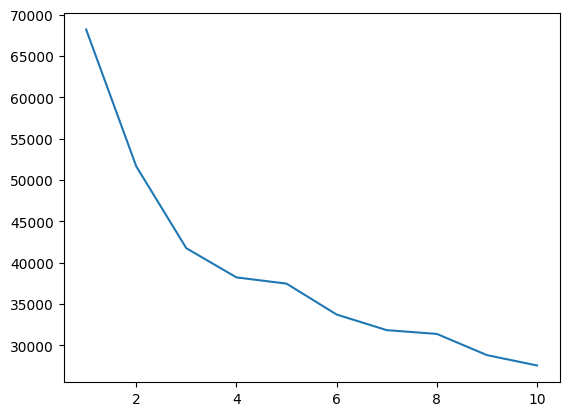

In [143]:
plt.plot(range(1, 11), wcss)

In [144]:
# based on kmean elbow plot, data can be divided into 3 clusters (furnished, semi furnished and unfurnished)

In [148]:
# fitting kmeans model with 3 clusters

n_clusters = 3

kmeans = KMeans(n_clusters=n_clusters, random_state = 42)
cluster_assignment = kmeans.fit_predict(scaled_data)
np.unique(cluster_assignment)

array([0, 1, 2], dtype=int32)

In [149]:
df['furnishing_type'] = cluster_assignment

In [150]:
df.head()

,property_type,society,sector,price_in_cr,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,super_built_up_area,built_up_area,carpet_area,servant room,study room,pooja room,store room,others,furnishing_type
0,house,independent,sector 105,0.60,11102.0,540.44,Plot area 60(50.17 sq.m.),8,4,3,not available,3.0,West,new,"['Chintapurni Mandir', 'State bank ATM', 'Bhar...","['9 Fan', '17 Light', 'No AC', 'No Bed', 'No C...","['Private Garden / Terrace', 'Park']",NaN,540.0,NaN,0,0,0,0,0,1
1,flat,vatika gurgaon,sector 83,1.18,6801.0,1735.04,Super Built up area 1735(161.19 sq.m.)Carpet a...,3,3,2,not available,14.0,north,relatively new,"['Huda Metro Station (Gurugram)', 'Sapphire 83...",NaN,"['Feng Shui / Vaastu Compliant', 'Lift(s)', 'M...",1735.00,NaN,1500.0,0,0,0,0,0,1
2,flat,emaar digihomes,sector 62,4.00,14871.0,2689.80,Super Built up area 2588.79(240.51 sq.m.),3,3,3,servant room,18.0,north,new,"['Sector 55-56 Metro Station', 'Omaxe Gurgaon ...","['6 Fan', '7 Light', '8 AC', '1 Modular Kitche...","['High Ceiling Height', 'Maintenance Staff', '...",2588.83,NaN,NaN,1,0,0,0,0,0
3,flat,ss the leaf,sector 85,1.10,6318.0,1741.06,Super Built up area 1741(161.74 sq.m.)Carpet a...,2,2,3+,store room,3.0,south-east,relatively new,"['Sapphire 83 Mall', 'Dwarka Expressway', 'Cen...","['10 Light', '4 AC', 'No Bed', 'No Chimney', '...","['Centrally Air Conditioned', 'Water purifier'...",1741.00,NaN,1218.0,0,0,0,1,0,1
4,flat,tarc maceo,sector 91,0.89,6339.0,1404.01,Super Built up area 1404(130.44 sq.m.)Carpet a...,2,2,3+,others,9.0,east,relatively new,"['Manish Gallexie 91', 'Dwarka Expressway', 'R...","['2 Wardrobe', '5 Fan', '1 Exhaust Fan', '1 Ge...","['Intercom Facility', 'Lift(s)', 'Maintenance ...",1404.00,NaN,1200.0,0,0,0,0,1,0


In [154]:
pd.set_option('display.max_colwidth', None)

In [ ]:
df[['furnishDetails', 'furnishing_type']]

# by looking at the kmeans output, we can say
#1 --> unfurnished
#2 --> furnished
#0 --> sem-furnished

,furnishDetails,furnishing_type
0,"['9 Fan', '17 Light', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Geyser', 'No Modular Kitchen', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']",1
1,NaN,1
2,"['6 Fan', '7 Light', '8 AC', '1 Modular Kitchen', '1 Chimney', 'No Bed', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Geyser', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']",0
3,"['10 Light', '4 AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Fan', 'No Geyser', 'No Modular Kitchen', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']",1
4,"['2 Wardrobe', '5 Fan', '1 Exhaust Fan', '1 Geyser', '4 Light', '1 Chimney', 'No AC', 'No Bed', 'No Curtains', 'No Dining Table', 'No Modular Kitchen', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']",0
5,"['2 Wardrobe', '1 Light', '1 Modular Kitchen', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Fan', 'No Geyser', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']",1
6,"['2 Wardrobe', '4 Fan', '1 Exhaust Fan', '1 Geyser', '1 Stove', '8 Light', '1 Modular Kitchen', '1 Curtains', '1 Chimney', '2 AC', 'No Bed', 'No Dining Table', 'No Microwave', 'No Fridge', 'No Sofa', 'No TV', 'No Washing Machine', 'No Water Purifier']",0
7,"['4 Wardrobe', '1 Water Purifier', '7 Fan', '1 Exhaust Fan', '5 Geyser', '25 Light', '6 AC', '1 Chimney', '1 Modular Kitchen', 'No Bed', 'No Curtains', 'No Dining Table', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine']",0
8,NaN,1
9,[],1
